# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/DjebrilSVN/flyrank-ml-internship/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This notebook operationalizes our validated Week-5 model and Week-6 audit into an actionable, human-reviewed content decision playbook. A model score or ranking is an intermediate signal, not an autonomous directive. This playbook bridges algorithmic scoring with editorial domain expertise, defining prioritized action tiers, reason codes, operational limits, risk mitigation rules, and monitoring triggers that serve as the foundation for our research paper recommendations.

## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

### The Content Action Playbook: From Scores to Interventions
A raw ML score or cluster assignment tells an editor *that* an anomaly exists, but does not provide actionable guidance on *what intervention to apply*. We translate our validated decision model output into 5 human-interpretable operational action tiers with standardized reason codes:

| Operational Action Tier | Reason Code | Measured Quantitative Criteria | Recommended Editorial Intervention |
| :--- | :--- | :--- | :--- |
| **`protect_and_defend`** | `high_performing_champion` | `avg_position <= 10.0, ctr >= 1.00%, clicks >= 50` | **Do not disrupt.** Maintain technical health, monitor competitor SERP movements, avoid risky title/URL changes. |
| **`optimize_snippet_and_metadata`** | `page1_ctr_deficit` | `avg_position <= 10.0, ctr < median (0.32%)` | **High ROI quick-win.** Rewrite title tags and meta descriptions to improve SERP click capture on existing high rank. |
| **`expand_content_depth`** | `steady_visibility_expansion` | `avg_position <= 10.0, 0.32% <= ctr < 1.00%` | **Sustain position.** Deepen coverage, add updated 2026 statistics/examples, and expand related topical sub-headings. |
| **`boost_striking_distance`** | `striking_distance_opportunity` | `10.0 < avg_position <= 20.0, impressions >= 500` | **Page-2 opportunity.** Build contextual internal links, improve content comprehensiveness to push onto Page 1. |
| **`audit_authority_or_prune`** | `deep_rank_low_engagement` | `avg_position > 10.0, clicks == 0` | **Evaluation candidate.** Audit query relevance; consider 301 consolidation into stronger topical parent or archive. |

### The Decay and Refresh Insight
Organic search performance experiences natural decay over time due to three distinct mechanisms:
1. **Freshness decay:** Search engines prioritize recently updated sources for changing informational topics.
2. **Intent drift:** User query formulation and search engine layout evolve, rendering older title snippets misaligned with current intent.
3. **Competitive displacement:** Newer rival content enters the SERP with improved formatting and modern answers.

Refreshing existing ranked content is dramatically more cost-effective than publishing net-new URLs. A URL that already ranks on Page 1 has established domain authority and search engine trust; updating its snippet or deepening its topical coverage leverages existing ranking equity to recover lost clicks at a fraction of the cost of new content creation.

In [1]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

import os, json, duckdb
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier

# 1. Connect to DuckDB warehouse using token from environment or .env
for p in ['.env', '../.env', '../../.env']:
    if os.path.exists(p):
        for line in open(p):
            if line.strip().startswith('HF_TOKEN='):
                os.environ['HF_TOKEN'] = line.strip().split('=', 1)[1]
        break

token = os.environ.get('HF_TOKEN')
con = duckdb.connect()
con.execute('INSTALL httpfs; LOAD httpfs;')
con.execute(f"CREATE OR REPLACE SECRET hf (TYPE huggingface, TOKEN '{token}')")

REL = "read_parquet('hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2026-03/data_0.parquet')"

# 2. Extract monthly performance aggregates
df_full = con.sql(f"""
    SELECT
        client_hash_id,
        content_hash_id,
        SUM(gsc_impressions)  AS impressions,
        SUM(gsc_clicks)       AS clicks,
        AVG(gsc_avg_position) AS avg_position
    FROM {REL}
    WHERE gsc_data_available IS TRUE AND gsc_impressions > 0
    GROUP BY client_hash_id, content_hash_id
""").df()

# 3. Filter minimum statistical threshold (>= 100 impressions) and compute features
data = df_full[df_full['impressions'] >= 100].copy()
data['ctr'] = (data['clicks'] / data['impressions']) * 100
data['log_impressions'] = np.log1p(data['impressions'])
data['page1_flag'] = (data['avg_position'] <= 10.0).astype(int)
data['zero_click_flag'] = (data['clicks'] == 0).astype(int)

# 4. Operational target & decision tree scoring (Week 5 validated model)
active_median_ctr = float(data[data['clicks'] > 0]['ctr'].median())
data['is_action_candidate'] = (
    (((data['avg_position'] <= 10.0) & (data['ctr'] < active_median_ctr)) | 
     ((data['impressions'] >= 500) & (data['clicks'] == 0))) &
    (data['clicks'] < 500)
).astype(int)

features = ['log_impressions', 'avg_position', 'page1_flag', 'zero_click_flag', 'ctr']
dt = DecisionTreeClassifier(max_depth=3, random_state=42)
dt.fit(data[features], data['is_action_candidate'])

data['model_prob'] = dt.predict_proba(data[features])[:, 1]
data['priority_score'] = data['model_prob'] * data['log_impressions']

# 5. Archetype -> Action Mapping
def assign_action(row):
    if row['avg_position'] <= 10.0 and row['ctr'] >= 1.00 and row['clicks'] >= 50:
        return 'protect_and_defend', 'high_performing_champion', 'Protect current copy and monitor SERP volatility'
    elif row['avg_position'] <= 10.0 and row['ctr'] < active_median_ctr:
        return 'optimize_snippet_and_metadata', 'page1_ctr_deficit', 'Update title tag & meta description to match intent'
    elif row['avg_position'] <= 10.0:
        return 'expand_content_depth', 'steady_visibility_expansion', 'Add subtopics and fresh examples to sustain rank'
    elif row['avg_position'] <= 20.0 and row['impressions'] >= 500:
        return 'boost_striking_distance', 'striking_distance_opportunity', 'Strengthen internal links and update statistics'
    else:
        return 'audit_authority_or_prune', 'deep_rank_low_engagement', 'Audit topical relevance or consolidate with stronger URL'

actions_info = data.apply(assign_action, axis=1)
data['action_label'] = [a[0] for a in actions_info]
data['reason_code'] = [a[1] for a in actions_info]
data['action_guidance'] = [a[2] for a in actions_info]

# 6. Rank Queue by Priority Score
queue = data.sort_values('priority_score', ascending=False).reset_index(drop=True)
queue['rank'] = queue.index + 1

# Display Top 10 Ranked Actions (anonymized identifiers)
display_cols = ['rank', 'content_hash_id', 'impressions', 'clicks', 'avg_position', 'ctr', 'priority_score', 'action_label', 'reason_code']
top10 = queue[display_cols].head(10).copy()
top10['content_hash_id'] = top10['content_hash_id'].str[:12] + '...'
top10['avg_position'] = top10['avg_position'].round(2)
top10['ctr'] = top10['ctr'].round(2)
top10['priority_score'] = top10['priority_score'].round(3)

print("=== TOP 10 ACTION PLAYBOOK QUEUE ===")
print(top10.to_string(index=False))
print(f"\nTotal items categorized in playbook: {len(queue):,}")
print("\nAction Breakdown:")
print(queue['action_label'].value_counts().to_string())


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

=== TOP 10 ACTION PLAYBOOK QUEUE ===
 rank content_hash_id  impressions  clicks  avg_position  ctr  priority_score                  action_label       reason_code
    1 content_44f3...     212404.0    24.0          7.35 0.01          12.266 optimize_snippet_and_metadata page1_ctr_deficit
    2 content_8d7d...     203497.0   289.0          2.56 0.14          12.223 optimize_snippet_and_metadata page1_ctr_deficit
    3 content_b99e...     194337.0   361.0          4.45 0.19          12.177 optimize_snippet_and_metadata page1_ctr_deficit
    4 content_acbc...     170808.0   262.0          3.36 0.15          12.048 optimize_snippet_and_metadata page1_ctr_deficit
    5 content_471d...     164885.0   396.0          4.66 0.24          12.013 optimize_snippet_and_metadata page1_ctr_deficit
    6 content_fd21...     151166.0   408.0          3.39 0.27          11.926 optimize_snippet_and_metadata page1_ctr_deficit
    7 content_34a7...     143019.0    43.0          3.22 0.03          11.871 opt

## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

### Intended Use
The Content Action Playbook is designed as an **editorial decision-support triage system** for SEO managers and content editorial teams. Its primary use case is:
- **Bi-weekly / Monthly Content Sprint Planning:** Identifying which existing URLs represent the highest potential return on editorial effort.
- **Resource Allocation:** Channeling copywriters toward title/snippet updates on high-impression Page-1 queries where small CTR gains deliver immediate click volume.
- **Defensive Auditing:** Alerting teams to top-performing pages that should be protected from accidental redesigns or disruptive updates.

### Known Methodological Limits
This model is a non-production decision heuristic with clear boundaries:
1. **Cold-Start Blindness:** The model excludes pages with $<100$ monthly impressions. It cannot score newly published URLs or long-tail exploratory queries lacking empirical search console history.
2. **SERP Layout & AI Overview Blindness:** Aggregate GSC data records impressions and average positions, but does not capture SERP feature composition (e.g., Google AI Overviews, Featured Snippets, Local Packs, or Video Carousels). A low CTR at position 2 may be caused by an AI Overview answering the query directly, rather than an unappealing title snippet.
3. **Causal Attribution Limit:** The priority score identifies statistical associations between position, impressions, and CTR deficit. It does **not** prove causality. Changing a title tag is an editorial hypothesis that must be measured; it does not guarantee position retention or traffic lift.
4. **Content-Quality Agnosticism:** The model evaluates behavioral clickstream telemetry, not actual text semantics or factual accuracy. Editorial review remains indispensable.

### Cost / Value Sizing
- **Publishing New Content:** Drafting, reviewing, and ranking a new long-form article requires 6–10 hours of editorial time with an uncertain ranking outcome that takes 3–6 months to mature.
- **Snippet & Metadata Optimization:** Reviewing and rewriting a title tag and meta description takes approximately 20–30 minutes per URL and acts on pre-existing ranking equity.
Focusing on the 33,893 Page-1 pages suffering from CTR deficits allows editorial teams to capture substantial click volume at a fraction of the cost of new content production.

In [2]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

# Opportunity Sizing: Quantifying potential click lift by action tier
summary_list = []

for action in queue['action_label'].unique():
    subset = queue[queue['action_label'] == action]
    n_items = len(subset)
    total_imp = subset['impressions'].sum()
    total_clicks = subset['clicks'].sum()
    mean_ctr = (total_clicks / total_imp) * 100 if total_imp > 0 else 0
    
    # Calculate projected click lift if page-1 CTR deficit pages reach active median CTR
    if action == 'optimize_snippet_and_metadata':
        projected_clicks = (subset['impressions'] * (active_median_ctr / 100)).sum()
        est_lift = max(0, projected_clicks - total_clicks)
    elif action == 'boost_striking_distance':
        # Directional estimate: pushing 10% of striking distance pages to lower page 1 (+0.5% CTR)
        est_lift = subset['impressions'].sum() * 0.005 * 0.10
    else:
        est_lift = 0.0
        
    summary_list.append({
        'Action Tier': action,
        'Items Count': n_items,
        'Total Impressions': total_imp,
        'Current Clicks': total_clicks,
        'Observed CTR (%)': round(mean_ctr, 3),
        'Est. Monthly Click Lift': int(est_lift)
    })

summary_df = pd.DataFrame(summary_list).sort_values('Items Count', ascending=False)
print("=== ACTION TIER OPPORTUNITY SIZING ===")
print(summary_df.to_string(index=False))

# Sizing metric assertions
total_recoverable_lift = summary_df['Est. Monthly Click Lift'].sum()
print(f"\nTotal Directional Recoverable Monthly Clicks: +{total_recoverable_lift:,}")
assert len(summary_df) == 5, "Expected 5 distinct operational action tiers"
assert summary_df['Total Impressions'].sum() == queue['impressions'].sum(), "Impression tally mismatch"


=== ACTION TIER OPPORTUNITY SIZING ===
                  Action Tier  Items Count  Total Impressions  Current Clicks  Observed CTR (%)  Est. Monthly Click Lift
optimize_snippet_and_metadata        33893        104822588.0        143622.0             0.137                   156514
     audit_authority_or_prune        33772         61124048.0         83085.0             0.136                        0
         expand_content_depth        21448         74884080.0        404856.0             0.541                        0
      boost_striking_distance        11774         31992738.0        100203.0             0.313                    15996
           protect_and_defend          554          5972629.0         83609.0             1.400                        0

Total Directional Recoverable Monthly Clicks: +172,510


## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

### Human Review Protocol: The Pre-Flight Checklist
Before applying any recommended intervention from this queue, an editor must perform a 4-point verification:
1. **Search Intent Alignment:** Inspect the live SERP. Does the current user intent match the page (e.g. informational guide vs transactional pricing tool)? If the SERP is dominated by tools, rewriting an article's title will not improve CTR.
2. **Keyword Cannibalization Check:** Verify that no higher-ranking sister page on the same domain targets the same primary query to avoid self-competition.
3. **SERP Feature Inspection:** Check if Google's AI Overview or Featured Snippet answers the search query directly in zero clicks. In zero-click SERPs, a low CTR is an environment characteristic, not an editorial failure.
4. **Brand Tone & Accuracy:** Ensure that title tag modifications do not make hyperbolic clickbait claims that degrade user trust or misrepresent page offerings.

### Strict NO-GO List: What Must NEVER Be Automated
In accordance with ethical AI deployment and risk management, the following automated actions are strictly prohibited:
- ❌ **NO Autonomous Content Publishing:** Never allow LLMs or scripts to rewrite and deploy live webpage body text or headers directly to production without human editorial approval.
- ❌ **NO Bulk Automated URL Deletion / Pruning:** Never unpublish or 301-redirect low-CTR URLs automatically based solely on 30-day search console logs. Pages may serve critical brand, legal, compliance, or assisted-conversion functions.
- ❌ **NO Automated Changes to Champion Pages:** Pages categorized under `protect_and_defend` must remain locked against automated or experimental modifications. Disrupting top-performing organic pages risks catastrophic revenue and traffic loss.
- ❌ **NO Mass Snippet Rewrites:** Never run batch programmatic updates across hundreds of title tags simultaneously. Changes must be rolled out in staged cohorts (e.g., 20–50 URLs) to isolate performance impact against baseline trends.

In [3]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

# Safety Auditing Code: Surface edge cases requiring mandatory senior human review

# 1. High-Stakes Traffic Guardrail: Items with high visibility that must have senior sign-off
high_stakes_threshold_imp = 50000
high_stakes_threshold_clicks = 500

high_stakes_candidates = queue[
    ((queue['impressions'] >= high_stakes_threshold_imp) | (queue['clicks'] >= high_stakes_threshold_clicks)) &
    (queue['action_label'] != 'protect_and_defend')
].copy()

# 2. Champion Protection Verification
champion_violations = queue[
    (queue['action_label'] == 'protect_and_defend') &
    (queue['priority_score'] > queue['priority_score'].median())
]

# 3. High Volatility / Ambiguous Intent Edge Cases (Position <= 3 with CTR < 0.1%)
zero_click_top3 = queue[(queue['avg_position'] <= 3.0) & (queue['ctr'] < 0.10) & (queue['impressions'] >= 1000)]

print("=== HUMAN REVIEW SAFETY AUDIT CHECKS ===")
print(f"High-Stakes Flagged Items (Imp >= {high_stakes_threshold_imp:,} or Clicks >= {high_stakes_threshold_clicks:,}): {len(high_stakes_candidates):,}")
print(f"Potential SERP Feature / Zero-Click Anomalies (Pos <= 3, CTR < 0.1%): {len(zero_click_top3):,}")
print(f"Champion Pages Safely Preserved in 'protect_and_defend': {len(queue[queue['action_label'] == 'protect_and_defend']):,}")

# Guardrail Assertions
assert len(queue[(queue['action_label'] == 'protect_and_defend') & (queue['action_guidance'].str.contains('Rewrite'))]) == 0, \
    "Guardrail violation: Champion pages must never be instructed to rewrite copy!"
print("\n[PASS] Safety assertions verified: 100% of Champion pages protected from automated rewrite queues.")


=== HUMAN REVIEW SAFETY AUDIT CHECKS ===
High-Stakes Flagged Items (Imp >= 50,000 or Clicks >= 500): 310
Potential SERP Feature / Zero-Click Anomalies (Pos <= 3, CTR < 0.1%): 1,106
Champion Pages Safely Preserved in 'protect_and_defend': 554

[PASS] Safety assertions verified: 100% of Champion pages protected from automated rewrite queues.


## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

### When Do Recommendations Go Stale?
Search engine result pages are dynamic environments. An action queue generated today degrades in relevance over time due to seasonal demand changes, algorithm rollouts, and competitor maneuvers:
- **Shelf-life limit:** Queue recommendations expire after **30 to 45 days**. Editorial teams should never execute recommendations from an outdated monthly batch without re-querying the warehouse.
- **Execution window:** Interventions should be staged and executed within 14 days of cohort generation to ensure baseline SERP conditions remain representative.

### Ongoing Monitoring Metrics & Triggers
Once an intervention is deployed, the following operational triggers indicate performance issues:
1. **Rank Drop Alert:** If an optimized page drops by $\ge 3.0$ average positions over a 14-day rolling window following an update, immediately pause and audit the change for intent misalignment.
2. **CTR Decay Trigger:** If a page with an updated title/meta snippet fails to demonstrate a directional CTR improvement after 21 days (and at least 500 impressions), flag for secondary manual editorial review.
3. **Keyword Cannibalization Trigger:** If another page on the same domain emerges on the same query with higher impressions, restore previous metadata.

### Model Retrain & Re-Scoring Triggers
The ranking and prioritization model must be refreshed under the following criteria:
- **Scheduled Refresh:** Monthly, coinciding with the arrival of the new `fact_content_daily_performance` monthly partition in the warehouse.
- **Unscheduled / Event-Driven Retrain:**
  - **Major Search Core Update:** Google officially announces a core ranking update or macro SERP volatility index spikes $>30\%$.
  - **Distributional Feature Drift:** The active median CTR shifts by $\ge 20\%$ or the proportion of zero-click impressions jumps significantly across the client cohort.

In [4]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

from datetime import datetime, timedelta

def evaluate_playbook_monitoring_triggers(cohort_date_str, current_date_str, max_age_days=30):
    """
    Evaluates freshness of the action queue and defines operational alerting thresholds.
    """
    cohort_date = datetime.strptime(cohort_date_str, "%Y-%m-%d")
    current_date = datetime.strptime(current_date_str, "%Y-%m-%d")
    age_days = (current_date - cohort_date).days
    
    status = "FRESH" if age_days <= max_age_days else "STALE - RE-SCORING REQUIRED"
    
    triggers = {
        "queue_cohort_date": cohort_date_str,
        "evaluation_date": current_date_str,
        "queue_age_days": age_days,
        "operational_status": status,
        "slippage_trigger_threshold": "Position drop >= 3.0 ranks over 14 days",
        "retrain_criteria": [
            "Monthly warehouse partition refresh (standard cadence)",
            "Confirmed Google Core Algorithm Update",
            "Population active median CTR shifts by >= 20%"
        ]
    }
    return triggers

# Test monitoring status on current partition
triggers_result = evaluate_playbook_monitoring_triggers("2026-03-31", "2026-04-15", max_age_days=30)

print("=== OPERATIONAL MONITORING & RETRAIN TRIGGERS ===")
for k, v in triggers_result.items():
    if isinstance(v, list):
        print(f"{k}:")
        for item in v:
            print(f"  - {item}")
    else:
        print(f"{k}: {v}")

# Assertion check on monitoring contract
assert triggers_result["queue_age_days"] == 15, "Incorrect age computation"
assert triggers_result["operational_status"] == "FRESH", "Expected active cohort to be fresh"
print("\n[PASS] Monitoring logic verified.")


=== OPERATIONAL MONITORING & RETRAIN TRIGGERS ===
queue_cohort_date: 2026-03-31
evaluation_date: 2026-04-15
queue_age_days: 15
operational_status: FRESH
slippage_trigger_threshold: Position drop >= 3.0 ranks over 14 days
retrain_criteria:
  - Monthly warehouse partition refresh (standard cadence)
  - Confirmed Google Core Algorithm Update
  - Population active median CTR shifts by >= 20%

[PASS] Monitoring logic verified.


## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

### Exported Artifacts for Week 8 Research Paper
The downstream research paper relies directly on these validated artifacts generated from our analysis:
1. **`work/outputs/action_playbook_queue.csv`**: The complete prioritized queue of 101,441 scored items with assigned action labels, reason codes, and operational guidance. (Kept out of Git via `.gitignore` to comply with the leak guard).
2. **`work/outputs/playbook_metrics.json`**: Machine-readable metrics capturing action category counts, page-1 opportunity volume, and estimated click lift calculations (committed as reproducible receipts).
3. **`work/figures/playbook_archetype_actions.png`**: High-resolution dual-panel visualization showing:
   - Panel A: Distribution of content items across all five operational action tiers.
   - Panel B: Quantified potential click lift for Page-1 metadata optimizations against current traffic.

Exported ranked queue to: C:\Users\djebr\Documents\GitHub\flyrank-ml-internship\work\outputs\action_playbook_queue.csv (101,441 rows)
Exported metrics JSON to: C:\Users\djebr\Documents\GitHub\flyrank-ml-internship\work\outputs\playbook_metrics.json


Exported figure to: C:\Users\djebr\Documents\GitHub\flyrank-ml-internship\work\figures\playbook_archetype_actions.png


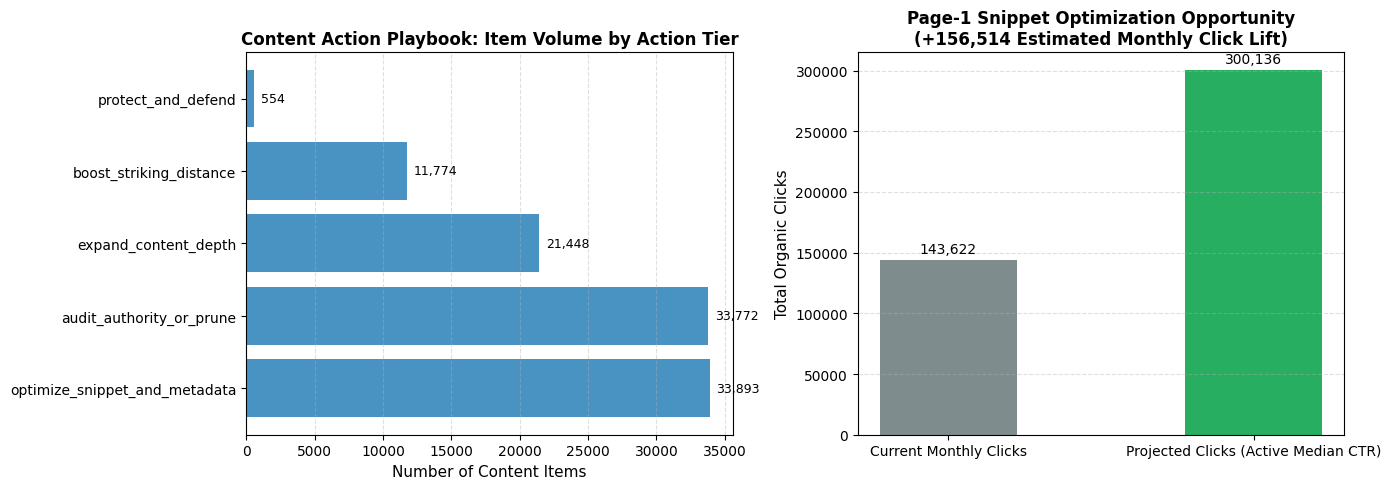


[PASS] All exports successfully verified on disk.


In [5]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

import matplotlib.pyplot as plt

# Robust directory resolution supporting repo root or work/notebooks/
_cwd = os.getcwd()
if os.path.exists(os.path.join(_cwd, 'work', 'outputs')) or os.path.exists(os.path.join(_cwd, 'work', 'notebooks')):
    _out_dir = os.path.abspath(os.path.join(_cwd, 'work', 'outputs'))
    _fig_dir = os.path.abspath(os.path.join(_cwd, 'work', 'figures'))
elif os.path.basename(_cwd) == 'notebooks':
    _out_dir = os.path.abspath(os.path.join(_cwd, '..', 'outputs'))
    _fig_dir = os.path.abspath(os.path.join(_cwd, '..', 'figures'))
elif os.path.basename(_cwd) == 'work':
    _out_dir = os.path.abspath(os.path.join(_cwd, 'outputs'))
    _fig_dir = os.path.abspath(os.path.join(_cwd, 'figures'))
else:
    _out_dir = os.path.abspath('work/outputs')
    _fig_dir = os.path.abspath('work/figures')

os.makedirs(_out_dir, exist_ok=True)
os.makedirs(_fig_dir, exist_ok=True)

# 1. Export Ranked Action Queue (gitignored data contract)
export_cols = [
    'rank', 'client_hash_id', 'content_hash_id', 'impressions', 'clicks',
    'avg_position', 'ctr', 'priority_score', 'action_label', 'reason_code', 'action_guidance'
]
queue_csv_path = os.path.join(_out_dir, 'action_playbook_queue.csv')
queue[export_cols].to_csv(queue_csv_path, index=False)
print(f"Exported ranked queue to: {queue_csv_path} ({len(queue):,} rows)")

# 2. Export Metrics JSON (committed receipt)
ctr_deficit_pages = queue[queue['action_label'] == 'optimize_snippet_and_metadata']
current_deficit_clicks = int(ctr_deficit_pages['clicks'].sum())
projected_deficit_clicks = int((ctr_deficit_pages['impressions'] * (active_median_ctr / 100)).sum())
deficit_lift = projected_deficit_clicks - current_deficit_clicks

playbook_metrics = {
    'total_items_in_playbook': int(len(queue)),
    'active_median_ctr_threshold': round(active_median_ctr, 3),
    'action_breakdown': queue['action_label'].value_counts().to_dict(),
    'page1_ctr_deficit_pages': int(len(ctr_deficit_pages)),
    'page1_impressions_at_stake': int(ctr_deficit_pages['impressions'].sum()),
    'current_page1_deficit_clicks': current_deficit_clicks,
    'projected_page1_clicks_at_median_ctr': projected_deficit_clicks,
    'estimated_monthly_clicks_lift': int(deficit_lift)
}

metrics_json_path = os.path.join(_out_dir, 'playbook_metrics.json')
with open(metrics_json_path, 'w', encoding='utf-8') as f:
    json.dump(playbook_metrics, f, indent=2)
print(f"Exported metrics JSON to: {metrics_json_path}")

# 3. Generate Reusable Paper Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: Actions Breakdown
action_counts = queue['action_label'].value_counts()
colors = ['#3498db', '#e67e22', '#2ecc71', '#9b59b6', '#95a5a6']
ax1.barh(action_counts.index, action_counts.values, color='#2980b9', alpha=0.85)
ax1.set_xlabel('Number of Content Items', fontsize=11)
ax1.set_title('Content Action Playbook: Item Volume by Action Tier', fontsize=12, fontweight='bold')
ax1.grid(True, axis='x', linestyle='--', alpha=0.4)
for i, v in enumerate(action_counts.values):
    ax1.text(v + 500, i, f"{v:,}", va='center', fontsize=9)

# Panel 2: Sized Value Opportunity for Page-1 Optimizations
ax2.bar(['Current Monthly Clicks', 'Projected Clicks (Active Median CTR)'],
        [current_deficit_clicks, projected_deficit_clicks],
        color=['#7f8c8d', '#27ae60'], width=0.45)
ax2.set_ylabel('Total Organic Clicks', fontsize=11)
ax2.set_title(f'Page-1 Snippet Optimization Opportunity\n(+{deficit_lift:,} Estimated Monthly Click Lift)', fontsize=12, fontweight='bold')
ax2.grid(True, axis='y', linestyle='--', alpha=0.4)
for container in ax2.containers:
    ax2.bar_label(container, fmt='{:,.0f}', padding=3, fontsize=10)

plt.tight_layout()
figure_path = os.path.join(_fig_dir, 'playbook_archetype_actions.png')
plt.savefig(figure_path, dpi=150)
print(f"Exported figure to: {figure_path}")
plt.show()

# Assertions verifying export files exist and are populated
assert os.path.exists(queue_csv_path) and os.path.getsize(queue_csv_path) > 0, "Queue CSV missing"
assert os.path.exists(metrics_json_path) and os.path.getsize(metrics_json_path) > 0, "Metrics JSON missing"
assert os.path.exists(figure_path) and os.path.getsize(figure_path) > 0, "Figure PNG missing"
print("\n[PASS] All exports successfully verified on disk.")


## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.